In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier
from data_processing.reporting.plotting import plot_fom
from scipy.optimize import curve_fit

In [2]:
ROOT = Path("C:/Users/Neutron Computer/Desktop/MATLAB Results/Maddy's experiment Oct 14, 22/echem_exp")
AMPLITUDES_PATH = ROOT / "amplitudes.csv"
PSD_PATH =  ROOT / "psd.csv"

In [3]:
psd = pd.read_csv(PSD_PATH, header=None)
amplitudes = pd.read_csv(AMPLITUDES_PATH, header=None)

psd_report = pd.concat([psd, amplitudes], axis=1)
psd_report.columns = ["tail / total", "amplitude"]
psd_report.head()

,tail / total,amplitude
0,0.26596,0.20995
1,0.22053,0.35119
2,0.19655,0.48497
3,0.23237,0.80665
4,0.22417,1.03830


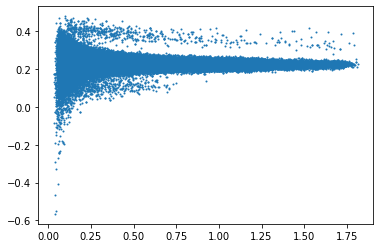

In [4]:
plt.scatter(psd_report["amplitude"], psd_report["tail / total"], s=1 )

In [5]:
cutoff_voltage = 0.45
restricted = psd_report[psd_report["tail / total"].between(0, 0.5)]
restricted = psd_report[psd_report["amplitude"] >= cutoff_voltage]

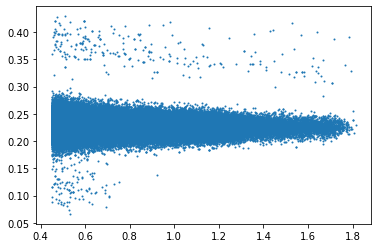

In [6]:
plt.scatter(restricted["amplitude"], restricted["tail / total"], s=1)

In [36]:
def fit_gauss(counts, bins):
    params, cov = curve_fit(gaussian, bins[:-1], counts)
    return abs(params), cov

gamma_counts, gamma_bins = np.histogram(gammas.loc["tail / total"], 100)
gamma_params, cov = fit_gauss(gamma_counts, gamma_bins)

In [9]:
neutrons, gammas = n_sigma_classifier(
    restricted.T, gamma_params, 10
)

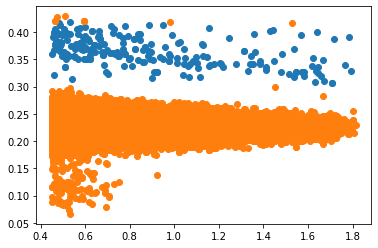

In [10]:
plt.scatter(neutrons.loc["amplitude"], neutrons.loc["tail / total"])
plt.scatter(gammas.loc["amplitude"], gammas.loc["tail / total"])

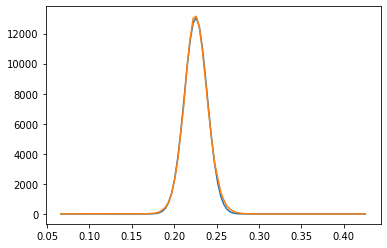

In [41]:
plt.plot(gamma_bins[:-1], gaussian(gamma_bins[:-1], *gamma_params))
plt.plot(gamma_bins[:-1], gamma_counts)

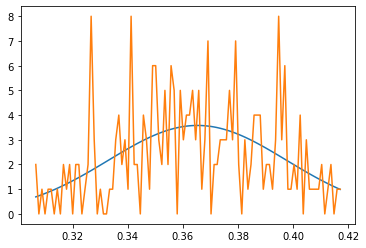

In [35]:
neutron_counts, neutron_bins = np.histogram(neutrons.loc["tail / total"], 100)
neutron_params, cov = fit_gauss(neutron_counts, neutron_bins)

plt.plot(neutron_bins[:-1], gaussian(neutron_bins[:-1], *neutron_params))
plt.plot(neutron_bins[:-1], neutron_counts)

In [20]:
FOM(*gamma_params[:2], *neutron_params[0:2])

1.2894786720924427

(0.1, 0.5)

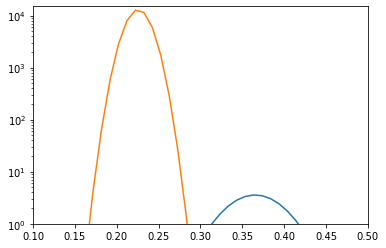

In [75]:
psd_space = np.linspace(0, 1, 100)
plt.plot(
    psd_space, gaussian(psd_space, *neutron_params)
)

plt.plot(
    psd_space, gaussian(psd_space, *gamma_params)
)

plt.yscale("log")
plt.ylim(1, 15000)
plt.xlim(0.1,0.5)

# FOM Optimization